# dLEM: pushing to fine resolution on a whole chromosome

Chromosome 1 -- the largest human chromosome, ~249 Mb -- fit whole and at 1 kb resolution
in a single `dlem.fit()` call, trained to `train_to=950`, the deepest depth that fits in
24.5 GB of GPU memory.

Requires the full local H1-hESC `.mcool` (~13 GB, not bundled) -- adjust `MCOOL` below to
reproduce. Section 2 checks that the fitted barrier profile is resolution-independent,
using the small, git-tracked chr10 fixture.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
from IPython.display import display

import dlem
from dlem.viz import band_to_dense, _resolve_cmap

print('dlem loaded from:', dlem.__file__)

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


dlem loaded from: /home/tis97/dlem/dlem/__init__.py


## 1. Fit the whole of chr1 at 1kb resolution, in one go

`width=950` extracts exactly the 950 diagonals we're going to train on -- no headroom for
extrapolation, since the point here is to demonstrate direct training at real
whole-chromosome, finest-resolution scale, not extrapolation past it.

In [2]:
MCOOL = "/home/tis97/data2/loop_extrusion_project/4DNucleome/H1hESC.mcool"  # H1-hESC, 4DNFI9GMP2J8 -- local copy required, ~13GB, not bundled
RESOLUTION = 1_000
CHROM = "chr1"
TRAIN_TO = 950   # 950 kb -- the largest safe train_to found on a 24.5GB GPU for this band

t0 = time.time()
band_chr1 = dlem.load_band(MCOOL, resolution=RESOLUTION, chrom=CHROM, width=TRAIN_TO, verbose=True)
t_extract = time.time() - t0
print(f"chr1 @ 1kb: band shape {band_chr1.shape}, extracted in {t_extract:.1f}s")

t0 = time.time()
fit_chr1 = dlem.fit(band_chr1, s=0.0025, train_to=TRAIN_TO, n_opt=1500, verbose=True)
t_fit = time.time() - t0
print(f"\nfit: {t_fit:.1f}s   mse={fit_chr1.mse:.4f}  corr={fit_chr1.corr:.4f}")

[band] fetching chr1 @ 1000 width=950 ...


/home/tis97/mambaforge/envs/dlem-port/lib/python3.11/site-packages/cooltools/lib/numutils.py:1376: RuntimeWarning: invalid value encountered in divide
  val_cur = ar_cur / armask_cur


[band] cached -> /home/tis97/dlem/band_cache/band_chr1_1000_950_605fdf71cb2e4a1a.npy
chr1 @ 1kb: band shape (950, 248957), extracted in 357.0s
  [   0] loss=12.4219  mse=0.3969  corr=0.4917  corr(L,R)=+0.3785
  [  25] loss=12.3854  mse=0.2854  corr=0.5753  corr(L,R)=+0.3439
  [  50] loss=12.3671  mse=0.2201  corr=0.6596  corr(L,R)=+0.2495
  [  75] loss=12.3603  mse=0.1873  corr=0.7138  corr(L,R)=+0.2069
  [ 100] loss=12.3577  mse=0.1730  corr=0.7407  corr(L,R)=+0.2497
  [ 125] loss=12.3566  mse=0.1699  corr=0.7483  corr(L,R)=+0.2503
  [ 150] loss=12.3560  mse=0.1690  corr=0.7509  corr(L,R)=+0.2096
  [ 175] loss=12.3557  mse=0.1686  corr=0.7521  corr(L,R)=+0.1565
  [ 200] loss=12.3555  mse=0.1682  corr=0.7530  corr(L,R)=+0.0992
  [ 225] loss=12.3552  mse=0.1679  corr=0.7536  corr(L,R)=+0.0401
  [ 250] loss=12.3551  mse=0.1677  corr=0.7541  corr(L,R)=-0.0175
  [ 275] loss=12.3549  mse=0.1676  corr=0.7543  corr(L,R)=-0.0681
  [ 300] loss=12.3548  mse=0.1676  corr=0.7545  corr(L,R)=-0.1111

### Patch visualization

Same double-triangle convention as `quick_start.ipynb`: data O/E upper triangle, model O/E
lower triangle, `L` (blue) above, `R` (orange) to the right. Each patch is 900 kb wide --
inside the trained 950 kb depth, so this is a direct fit, not an extrapolation. Three
windows spread across chr1 (same loci used in the `dlemFR_eval` stress test that this
notebook distills; chr1:134-136 Mb was screened out there for a degenerate, near-flat
barrier profile).

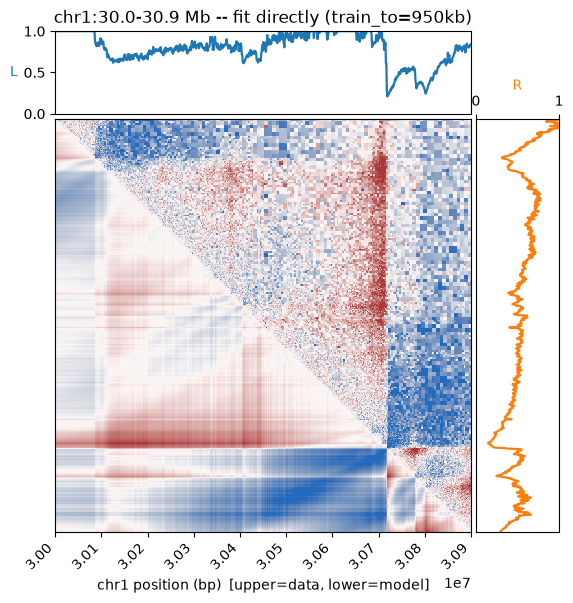

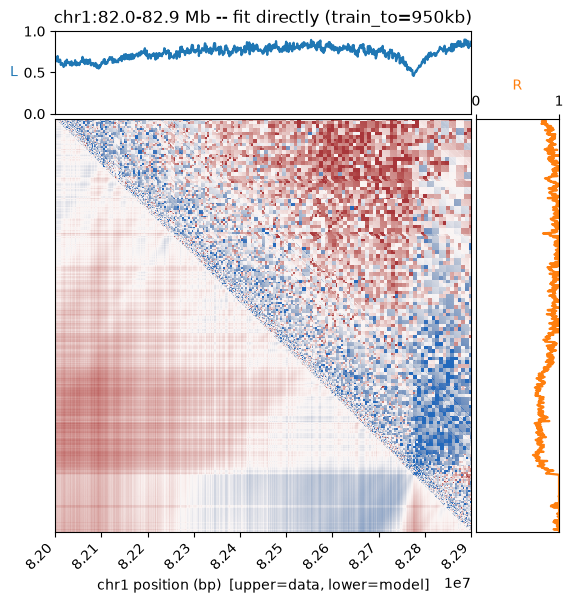

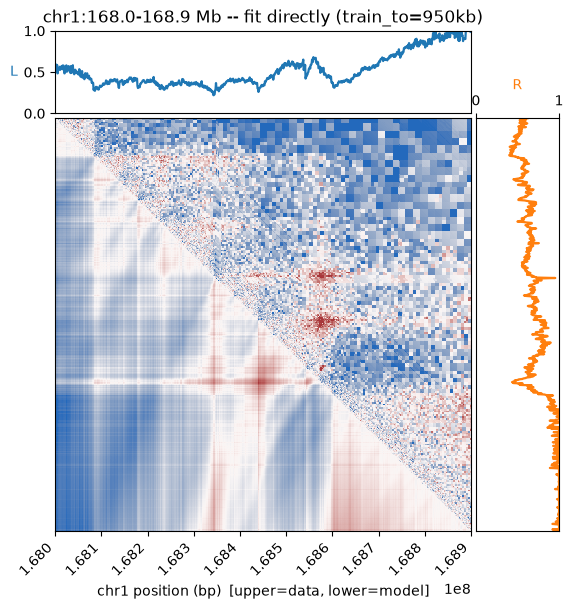

In [3]:
def plot_example_patch(fit, band, start, span, res, chrom, label, *, checkpoint=None, out=None):
    L, R = fit._LR(checkpoint)

    data_oe_band = dlem.normalize_oe(band)
    model_oe_band = dlem.normalize_oe(fit.predict(span, checkpoint=checkpoint))

    data_dense = band_to_dense(np.asarray(data_oe_band), start, start + span)
    model_dense = band_to_dense(np.asarray(model_oe_band), start, start + span)
    patch = np.triu(data_dense) + np.tril(model_dense, k=-1)

    v = float(np.nanpercentile(np.abs(patch[np.isfinite(patch)]), 98)) or 1.0

    start_coor, end_coor = start * res, (start + span) * res
    coords = np.arange(start, start + span) * res

    fig = plt.figure(figsize=(6.5, 6.5))
    gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.02, hspace=0.02,
                           height_ratios=[1, 5], width_ratios=[5, 1])
    ax_main = fig.add_subplot(gs[1, 0])
    ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

    ax_main.imshow(patch, extent=[start_coor, end_coor, end_coor, start_coor],
                  cmap=_resolve_cmap("vlag"), vmin=-v, vmax=v, aspect="auto",
                  interpolation="none")
    ax_main.set_xlabel(f"{chrom} position (bp)  [upper=data, lower=model]")
    ax_main.tick_params(labelleft=False, left=False)
    plt.setp(ax_main.get_xticklabels(), rotation=45, ha="right")

    ax_top.plot(coords, np.asarray(L)[start:start + span], lw=1.6, color="tab:blue")
    ax_top.set_ylim(0, 1)
    ax_top.set_ylabel("L", rotation=0, ha="right", va="center", color="tab:blue")
    ax_top.tick_params(labelbottom=False, bottom=False)
    ax_top.set_title(label)

    ax_right.plot(np.asarray(R)[start:start + span], coords, lw=1.6, color="tab:orange")
    ax_right.set_xlim(0, 1)
    ax_right.set_xlabel("R", color="tab:orange")
    ax_right.xaxis.set_label_position("top")
    ax_right.tick_params(labelleft=False, left=False, labeltop=True, top=True,
                         labelbottom=False, bottom=False)

    if out:
        fig.savefig(out, dpi=150, bbox_inches="tight")
    return fig


PATCH_SPAN = 900   # 900kb -- within the 950kb trained depth, no extrapolation
patch_starts_kb = [30_000, 82_000, 168_000]   # chr1 positions, kb

for i, start in enumerate(patch_starts_kb):
    start_mb, end_mb = start / 1000, (start + PATCH_SPAN) / 1000
    label = f"chr1:{start_mb:.1f}-{end_mb:.1f} Mb -- fit directly (train_to=950kb)"
    fig = plot_example_patch(fit_chr1, band_chr1, start, PATCH_SPAN, 1_000, "chr1", label,
                        out=f"whole_chromosome_1kb_patch_{i}.png")
    display(fig)
    plt.close(fig)

## 2. Barrier profile is resolution-independent

Separate, small-scale check: fit the same locus at 1kb and 10kb resolution (the small,
git-tracked chr10 fixture, chr10:19-26 Mb) with `s` rescaled proportionally to bin size
(`s=0.025` @10kb &harr; `s=0.0025` @1kb), and compare `L`/`R`. This confirms resolution
choice doesn't change the underlying barrier landscape -- pick whichever resolution is
cheapest for the depth you need.

[band] cache hit /home/tis97/dlem/band_cache/band_ref_region_10000_700_1241ac6cc9d0dcc8.npy
[band] cache hit /home/tis97/dlem/band_cache/band_ref_region_1000_7000_2aefc535c46a0cf9.npy
10kb: mse=0.1156  corr=0.8365
1kb:  mse=0.1663  corr=0.7701


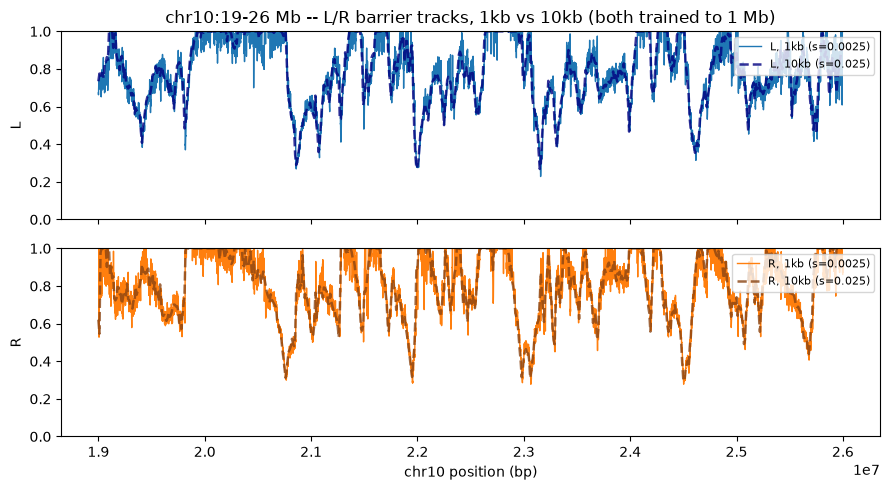

corr(L_1kb_downsampled, L_10kb) = 0.9842
corr(R_1kb_downsampled, R_10kb) = 0.9767


In [4]:
CHR10 = "ref_region"
GENOMIC_OFFSET_BP = int(19.0 * 1e6)   # bin 0 -> chr10:19,000,000
TRAIN_TO_CHR10_10KB, TRAIN_TO_CHR10_1KB = 100, 1000   # both 1 Mb

band_chr10_10kb = dlem.load_band("data/example_chr10.cool", resolution=10_000, chrom=CHR10, width=700)
band_chr10_1kb = dlem.load_band("data/example_chr10_1kb.cool", resolution=1_000, chrom=CHR10, width=7000)

fit_chr10_10kb = dlem.fit(band_chr10_10kb, s=0.025, train_to=TRAIN_TO_CHR10_10KB, n_opt=1500, verbose=False)
fit_chr10_1kb = dlem.fit(band_chr10_1kb, s=0.0025, train_to=TRAIN_TO_CHR10_1KB, n_opt=1500, verbose=False)

print(f"10kb: mse={fit_chr10_10kb.mse:.4f}  corr={fit_chr10_10kb.corr:.4f}")
print(f"1kb:  mse={fit_chr10_1kb.mse:.4f}  corr={fit_chr10_1kb.corr:.4f}")

L_10kb, R_10kb = np.asarray(fit_chr10_10kb.L), np.asarray(fit_chr10_10kb.R)
L_1kb, R_1kb = np.asarray(fit_chr10_1kb.L), np.asarray(fit_chr10_1kb.R)
coords_10kb = GENOMIC_OFFSET_BP + np.arange(700) * 10_000
coords_1kb = GENOMIC_OFFSET_BP + np.arange(7000) * 1_000

fig, (ax_L, ax_R) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax_L.plot(coords_1kb, L_1kb, lw=1.0, color="tab:blue", label="L, 1kb (s=0.0025)")
ax_L.plot(coords_10kb, L_10kb, lw=1.8, color="navy", ls="--", alpha=0.8, label="L, 10kb (s=0.025)")
ax_L.set_ylabel("L"); ax_L.set_ylim(0, 1)
ax_L.legend(loc="upper right", fontsize=8)
ax_L.set_title("chr10:19-26 Mb -- L/R barrier tracks, 1kb vs 10kb (both trained to 1 Mb)")

ax_R.plot(coords_1kb, R_1kb, lw=1.0, color="tab:orange", label="R, 1kb (s=0.0025)")
ax_R.plot(coords_10kb, R_10kb, lw=1.8, color="saddlebrown", ls="--", alpha=0.8, label="R, 10kb (s=0.025)")
ax_R.set_ylabel("R"); ax_R.set_ylim(0, 1)
ax_R.set_xlabel("chr10 position (bp)")
ax_R.legend(loc="upper right", fontsize=8)
fig.tight_layout()
display(fig)
plt.close(fig)

L_1kb_ds = L_1kb.reshape(700, 10).mean(axis=1)
R_1kb_ds = R_1kb.reshape(700, 10).mean(axis=1)
print(f"corr(L_1kb_downsampled, L_10kb) = {np.corrcoef(L_1kb_ds, L_10kb)[0,1]:.4f}")
print(f"corr(R_1kb_downsampled, R_10kb) = {np.corrcoef(R_1kb_ds, R_10kb)[0,1]:.4f}")

## Findings

- **A whole chromosome fits at 1kb resolution in a single `dlem.fit()` call.** chr1
  (~249,000 bins at 1kb) trained to 950 kb depth completes directly -- no chunking, no
  tiling across the chromosome -- with real barrier structure visible in the patches above.
- **950 kb is deliberately near the practical limit, not a comfortable default.**
  `full_rollout_selfnorm` memory scales with `train_to x n_bins`; on this 24.5 GB GPU, an
  isolated-process memory scan of this exact band found `train_to=950` is the largest safe
  round depth and `train_to=975` reliably OOMs. This notebook is intentionally run at that
  edge to demonstrate it holds up there, not comfortably below it.
- **The barrier profile is resolution-independent.** With `s` rescaled proportionally to
  bin size, 1kb and 10kb fits of the same locus agree closely (see the correlation numbers
  in section 2) -- resolution choice is a cost/precision tradeoff, not a change in the
  underlying model of the chromatin.